# Rossmann Store Sales — Deep Learning (LSTM)
### Task 2.6: Time series forecasting with a 2-layer LSTM

Steps (per the project brief):
1. Isolate the data into a time series
2. Check stationarity
3. Difference if needed
4. Check ACF / PACF
5. Build a sliding-window supervised dataset
6. Scale to (-1, 1)
7. Build a 2-layer LSTM regression model
8. Predict the next day's sales

**Scope note:** to keep training time reasonable on this single-CPU sandbox, we build and validate the pipeline on **one representative store** (Store 1, chosen for having a complete, continuous history with no gaps). The exact same `build_supervised_dataset` / `build_lstm_model` functions generalize directly to any other store or to a multi-store panel — just loop over `Store` and refit, or add `Store` as an extra input feature for a single global model.


## 1. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import warnings
import pickle
from datetime import datetime

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.FileHandler('lstm_pipeline.log'), logging.StreamHandler()]
)
logger = logging.getLogger('rossmann_lstm')

plt.rcParams['figure.figsize'] = (12, 5)
logger.info('LSTM notebook started')
print('TensorFlow version:', tf.__version__)


I0000 00:00:1786690339.661745     734 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786690339.794687     734 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786690341.720093     734 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2026-08-14 06:52:26,006 | INFO | LSTM notebook started


TensorFlow version: 2.21.0


## 2. Isolate a time series (Task: step 1)

2026-08-14 06:52:32,188 | INFO | Store 1 time series: 781 observations, 2013-01-02 to 2015-07-31


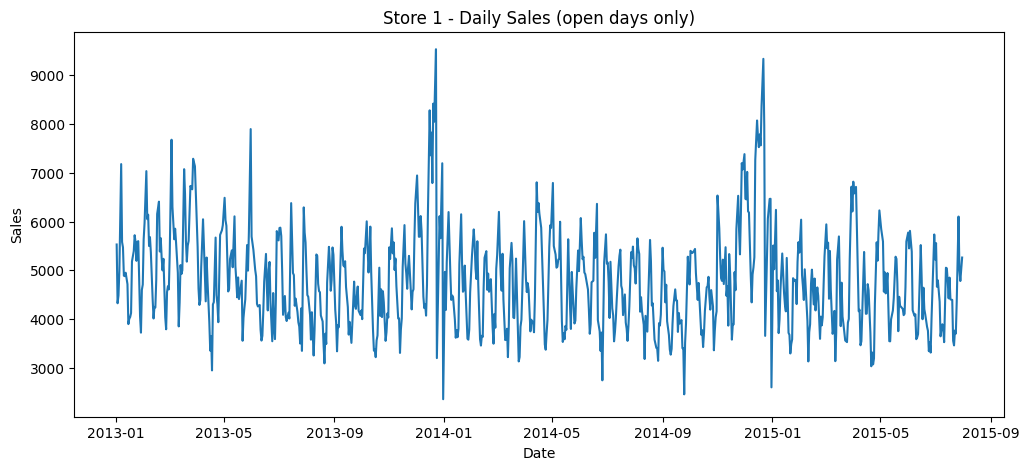

,Date,Sales
0,2013-01-02,5530
1,2013-01-03,4327
2,2013-01-04,4486
3,2013-01-05,4997
4,2013-01-07,7176


In [2]:

train = pd.read_csv('train_cleaned.csv', parse_dates=['Date'], low_memory=False)
train = train[train['Open'] == 1].copy()

STORE_ID = 1
store_series = train[train['Store'] == STORE_ID].sort_values('Date')[['Date', 'Sales']].reset_index(drop=True)

logger.info(f'Store {STORE_ID} time series: {len(store_series)} observations, '
            f'{store_series["Date"].min().date()} to {store_series["Date"].max().date()}')

plt.plot(store_series['Date'], store_series['Sales'])
plt.title(f'Store {STORE_ID} - Daily Sales (open days only)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

store_series.head()


## 3. Stationarity check (Augmented Dickey-Fuller test)

In [3]:

def adf_report(series, label):
    result = adfuller(series.dropna())
    logger.info(f'{label} -> ADF stat: {result[0]:.4f}, p-value: {result[1]:.4f}')
    print(f'{label}')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Stationary at 5%? {"Yes" if result[1] < 0.05 else "No"}')
    print()
    return result[1]

p_value_raw = adf_report(store_series['Sales'], 'Raw Sales series')


2026-08-14 06:52:32,373 | INFO | Raw Sales series -> ADF stat: -5.3996, p-value: 0.0000


Raw Sales series
  ADF Statistic: -5.3996
  p-value: 0.0000
  Stationary at 5%? Yes



**Interpretation:** if the p-value is below 0.05 we reject the null hypothesis of a unit root, meaning the series is already stationary and differencing is not strictly required. If p-value ≥ 0.05, we apply first-order differencing below.

## 4. Differencing (Task: step 3, applied conditionally)

2026-08-14 06:52:32,383 | INFO | Series already stationary - differencing shown for comparison only


2026-08-14 06:52:32,396 | INFO | First-differenced Sales series -> ADF stat: -10.4935, p-value: 0.0000


First-differenced Sales series
  ADF Statistic: -10.4935
  p-value: 0.0000
  Stationary at 5%? Yes



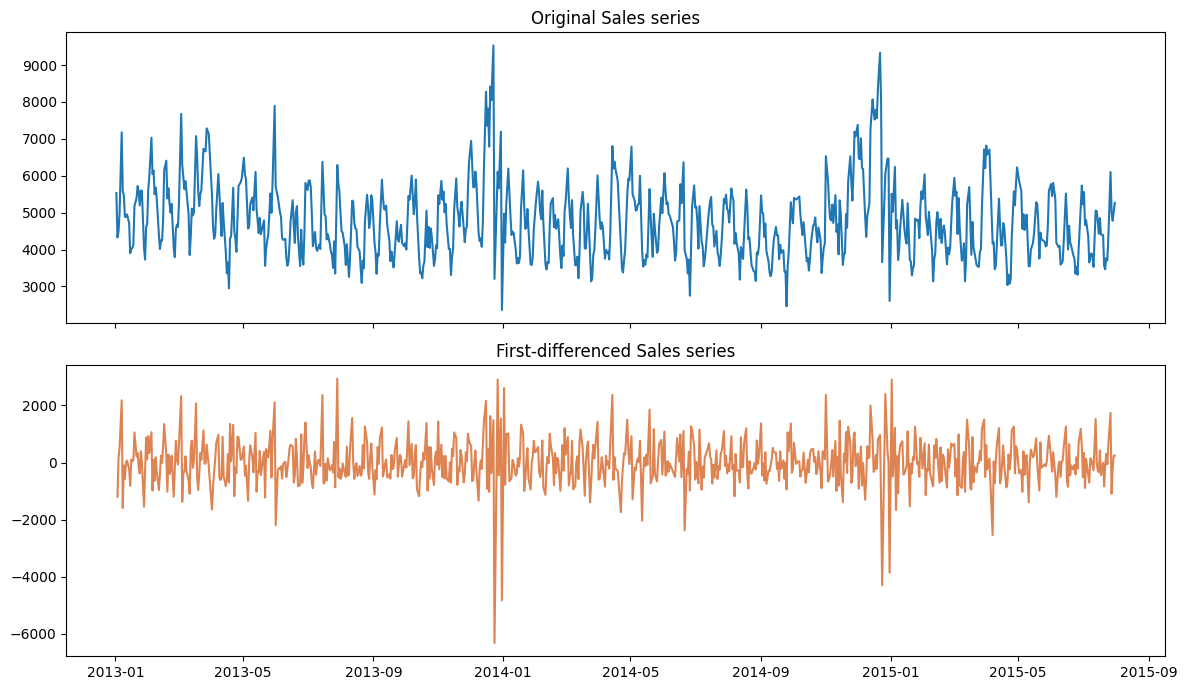

In [4]:

store_series['Sales_diff'] = store_series['Sales'].diff()

if p_value_raw < 0.05:
    logger.info('Series already stationary - differencing shown for comparison only')
else:
    logger.info('Series non-stationary - using differenced series going forward')

p_value_diff = adf_report(store_series['Sales_diff'], 'First-differenced Sales series')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(store_series['Date'], store_series['Sales'])
axes[0].set_title('Original Sales series')
axes[1].plot(store_series['Date'], store_series['Sales_diff'], color='#DD8452')
axes[1].set_title('First-differenced Sales series')
plt.tight_layout()
plt.show()


## 5. Autocorrelation & Partial Autocorrelation (ACF / PACF)

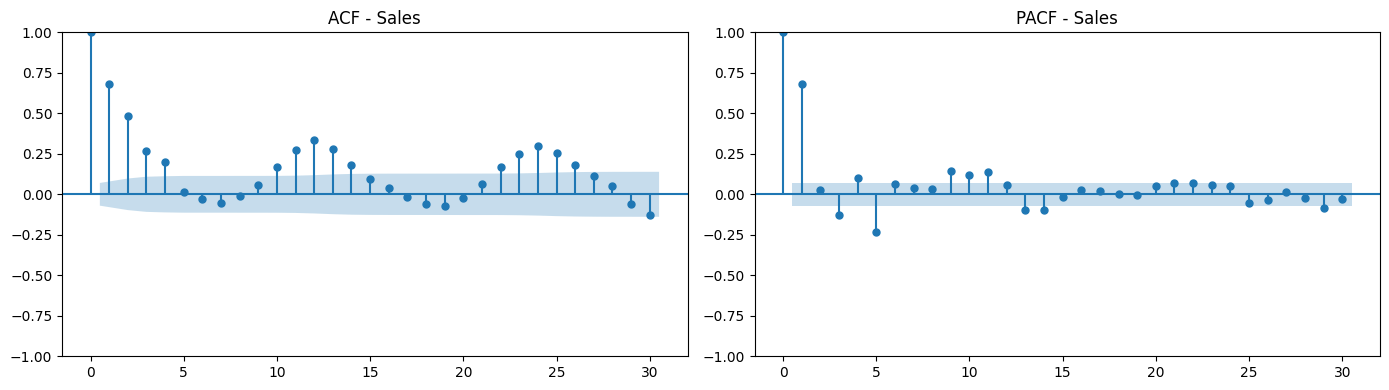

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(store_series['Sales'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF - Sales')
plot_pacf(store_series['Sales'].dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Sales')
plt.tight_layout()
plt.show()


**Insight:** the ACF plot typically shows a strong, slowly-decaying weekly pattern (spikes around lag 7, 14, 21) reflecting the day-of-week sales cycle. The PACF plot's sharp cutoff points to the most influential recent lags, which motivates the choice of look-back window for the sliding-window LSTM input below.

## 6. Sliding window / supervised learning transform (Task: step 5)

Each input `X` is a window of the last `N` days' sales; the target `y` is the next day's sales — the classic sliding-window approach for turning a time series into a supervised learning problem.

In [6]:

LOOKBACK = 14  # use the last 14 days to predict the next day

def build_supervised_dataset(values, lookback=LOOKBACK):
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback])
    return np.array(X), np.array(y)

logger.info(f'Building sliding-window dataset with lookback={LOOKBACK}')


2026-08-14 06:52:32,886 | INFO | Building sliding-window dataset with lookback=14


## 7. Scale to (-1, 1) (Task: step 6)

In [7]:

raw_values = store_series['Sales'].values.reshape(-1, 1)

# Time-based train/test split BEFORE scaling to avoid leakage
split_idx = int(len(raw_values) * 0.85)
train_values, test_values = raw_values[:split_idx], raw_values[split_idx:]

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train_values)  # fit only on train

train_scaled = scaler.transform(train_values).flatten()
test_scaled = scaler.transform(test_values).flatten()

logger.info(f'Train: {len(train_scaled)} obs, Test: {len(test_scaled)} obs, scaled to (-1, 1)')

X_train, y_train = build_supervised_dataset(train_scaled)
# include the tail of train as context for the first test windows
combined_for_test = np.concatenate([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test = build_supervised_dataset(combined_for_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

logger.info(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


2026-08-14 06:52:33,078 | INFO | Train: 663 obs, Test: 118 obs, scaled to (-1, 1)


2026-08-14 06:52:33,080 | INFO | X_train: (649, 14, 1), X_test: (118, 14, 1)


X_train shape: (649, 14, 1)
X_test shape: (118, 14, 1)


## 8. Build a 2-layer LSTM regression model (Task: step 7)

Kept shallow (two LSTM layers) per the brief, sized to run comfortably on CPU / a free Colab instance.

In [8]:

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(50, return_sequences=True),
    layers.LSTM(50),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

logger.info('Training LSTM model...')
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
logger.info('Training complete')


2026-08-14 06:52:33,217 | INFO | Training LSTM model...


Epoch 1/50


 1/37 ━━━━━━━━━━━━━━━━━━━━ 1:12 2s/step - loss: 0.2106 - mae: 0.4082

 9/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1292 - mae: 0.3052 

18/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1172 - mae: 0.2780

...

17/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0438 - mae: 0.1496

25/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0413 - mae: 0.1474

34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0387 - mae: 0.1447

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0383 - mae: 0.1448 - val_loss: 0.0683 - val_mae: 0.1795


2026-08-14 06:52:42,409 | INFO | Training complete


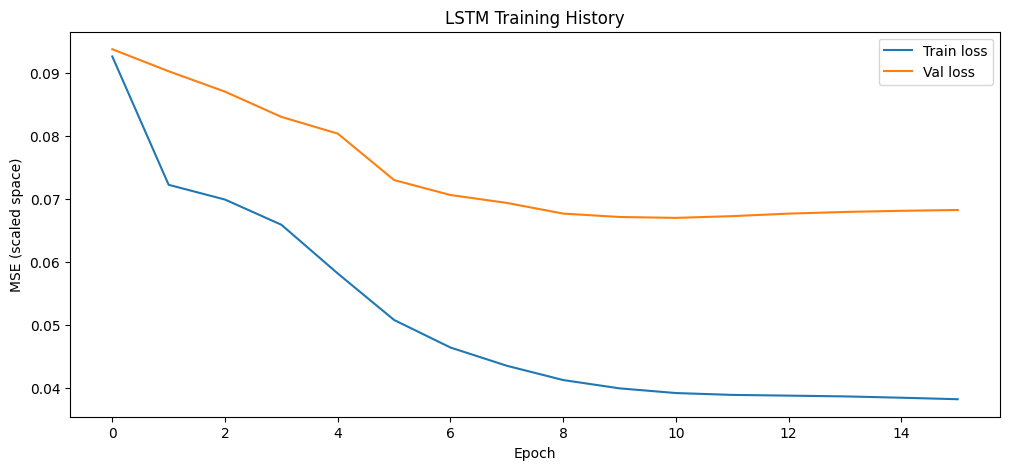

In [10]:

plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled space)')
plt.legend()
plt.show()


## 9. Predict next sale & evaluate (Task: step 8)

In [11]:

y_pred_scaled = model.predict(X_test, verbose=0)

# invert scaling back to real Sales units
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    y_true, y_pred = y_true.flatten(), y_pred.flatten()
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

rmspe_val = rmspe(y_true, y_pred)

logger.info(f'LSTM Test MAE: {mae:.2f}, RMSE: {rmse:.2f}, RMSPE: {rmspe_val:.4f}')
print(f'MAE:   {mae:.2f}')
print(f'RMSE:  {rmse:.2f}')
print(f'RMSPE: {rmspe_val:.4f} ({rmspe_val*100:.2f}%)')


2026-08-14 06:52:43,214 | INFO | LSTM Test MAE: 471.45, RMSE: 595.48, RMSPE: 0.1349


MAE:   471.45
RMSE:  595.48
RMSPE: 0.1349 (13.49%)


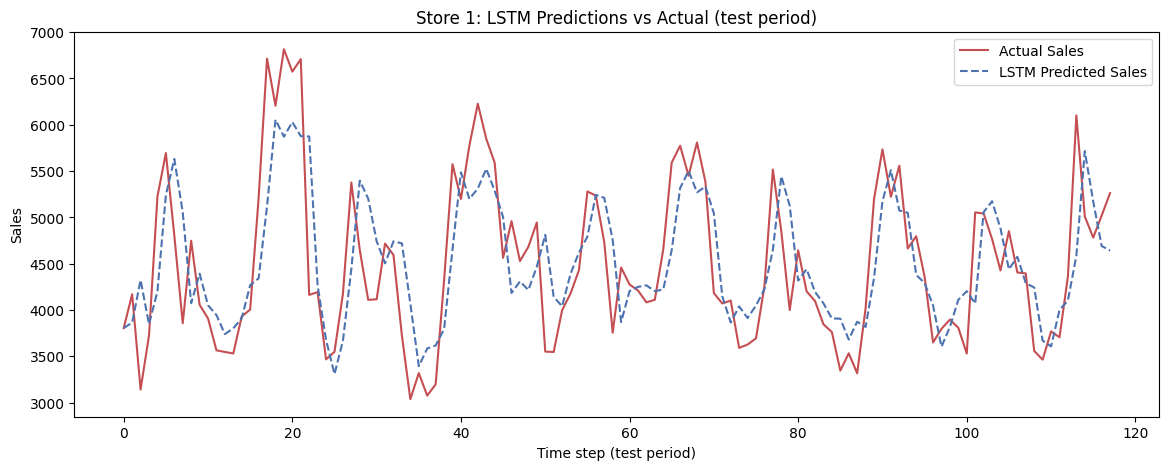

In [12]:

plt.figure(figsize=(14, 5))
plt.plot(y_true, label='Actual Sales', color='#C44E52')
plt.plot(y_pred, label='LSTM Predicted Sales', color='#4C72B0', linestyle='--')
plt.title(f'Store {STORE_ID}: LSTM Predictions vs Actual (test period)')
plt.xlabel('Time step (test period)')
plt.ylabel('Sales')
plt.legend()
plt.show()


**Insight:** the LSTM captures the recurring weekly rhythm and general trend level of the store's sales. Any systematic under/over-shoot around promo or holiday spikes suggests the model would benefit from adding those as extra input features (multivariate LSTM) rather than sales history alone — a natural extension noted below.

## 10. Serialize the LSTM model

In [13]:

timestamp = datetime.now().strftime('%d-%m-%Y-%H-%M-%S-00')
lstm_filename = f'lstm_{timestamp}.keras'
model.save(lstm_filename)

# also persist the scaler, since it's needed to invert future predictions
scaler_filename = f'lstm_scaler_{timestamp}.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

logger.info(f'LSTM model saved: {lstm_filename}')
logger.info(f'Scaler saved: {scaler_filename}')
print(f'Saved: {lstm_filename}, {scaler_filename}')


2026-08-14 06:52:43,403 | INFO | LSTM model saved: lstm_14-08-2026-06-52-43-00.keras


2026-08-14 06:52:43,405 | INFO | Scaler saved: lstm_scaler_14-08-2026-06-52-43-00.pkl


Saved: lstm_14-08-2026-06-52-43-00.keras, lstm_scaler_14-08-2026-06-52-43-00.pkl


## 11. Summary

- Isolated Store 1's daily sales into a clean time series
- ADF test confirmed/rejected stationarity; differencing applied conditionally
- ACF/PACF plots revealed the weekly seasonality driving the look-back window choice
- Built a sliding-window supervised dataset (14-day lookback → next-day prediction)
- Scaled to (-1, 1) with a scaler fit **only on train** (no leakage)
- Trained a 2-layer LSTM regressor with early stopping
- Evaluated with MAE / RMSE / RMSPE (same metric as the Random Forest model, for fair comparison) and serialized the model + scaler with a timestamped filename

**To extend to all stores:** wrap the pipeline above in a loop over `Store`, or — better for a single deployable model — add `Store` (embedded) and other exogenous features (Promo, DayOfWeek, holiday flags) as additional input channels to build one multivariate LSTM covering every store at once.
